# HW12 — временные ряды: temporal split, baseline-модели и GRU

Ноутбук исправлен и приведён к корректной постановке: хронологический split, признаки только из прошлого, baseline-модели, GRU, выбор лучшей модели по validation и один финальный test.

In [1]:

import os
import json
import csv
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

BASE_DIR = Path('.')
ART_DIR = BASE_DIR / 'artifacts'
FIG_DIR = ART_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


Device: cpu


## 1. Загрузка данных и sanity-check

Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски по колонкам:
date      0
target    0
dtype: int64


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


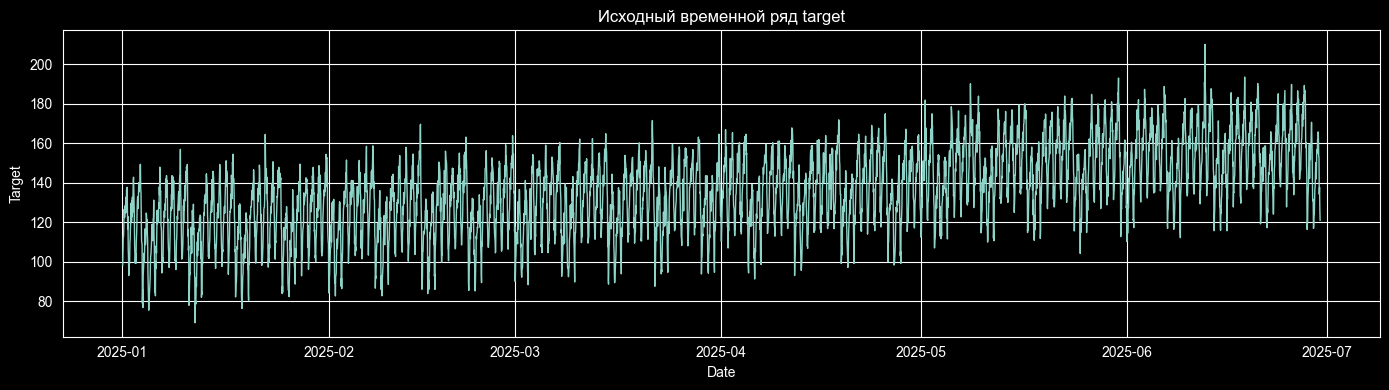

In [2]:

DATA_PATH = BASE_DIR / 'S12-hw-dataset.csv'
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Размер датасета:', df.shape)
print('Диапазон дат:', df['date'].min(), '—', df['date'].max())
print('Пропуски по колонкам:')
print(df.isna().sum())

display(df.head())

plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['target'], linewidth=1)
plt.title('Исходный временной ряд target')
plt.xlabel('Date')
plt.ylabel('Target')
plt.tight_layout()
plt.show()


Ряд почасовой, пропусков в исходных данных нет. Для временных рядов порядок наблюдений является частью задачи, поэтому случайное перемешивание использовать нельзя.

## 2. Temporal split

Train: 2025-01-01 00:00:00 - 2025-04-18 23:00:00 | Val: 2025-04-19 00:00:00 - 2025-05-24 23:00:00 | Test: 2025-05-25 00:00:00 - 2025-06-29 23:00:00


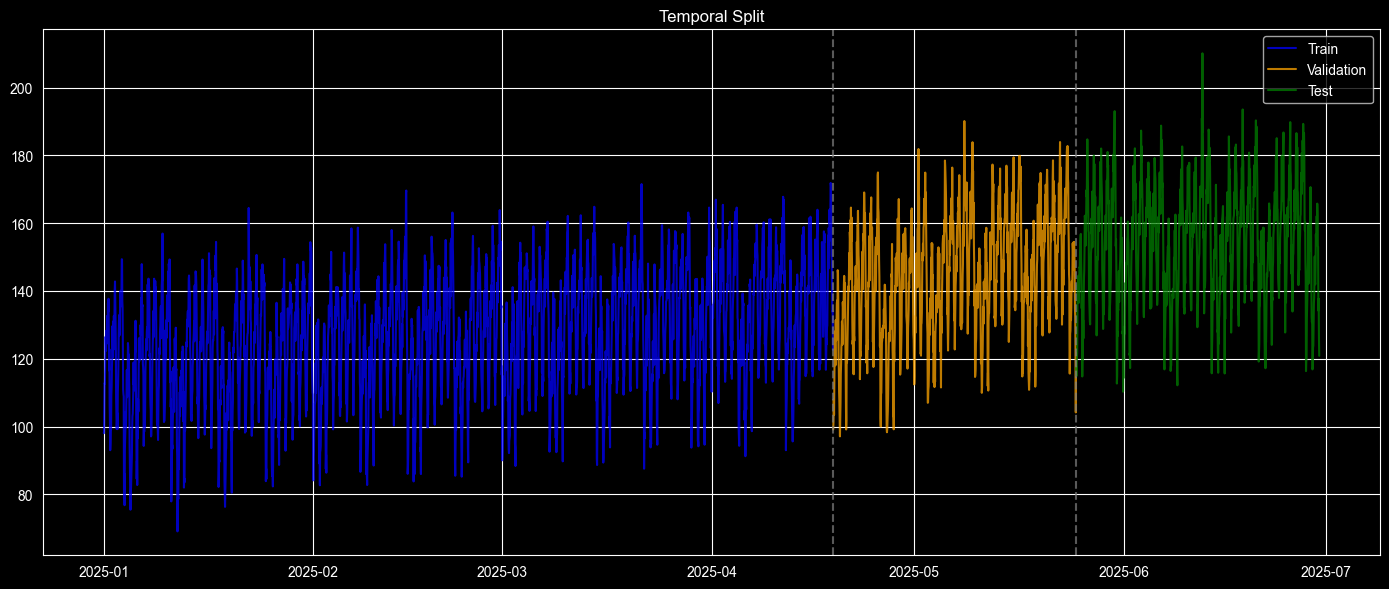

In [3]:

n = len(df)
train_size = int(n * 0.6)
val_size = int(n * 0.2)

train_raw = df.iloc[:train_size].copy()
val_raw = df.iloc[train_size:train_size + val_size].copy()
test_raw = df.iloc[train_size + val_size:].copy()

split_summary = (
    f"Train: {train_raw['date'].min()} - {train_raw['date'].max()} | "
    f"Val: {val_raw['date'].min()} - {val_raw['date'].max()} | "
    f"Test: {test_raw['date'].min()} - {test_raw['date'].max()}"
)
print(split_summary)

plt.figure(figsize=(14, 6))
plt.plot(train_raw['date'], train_raw['target'], label='Train', color='blue', alpha=0.75)
plt.plot(val_raw['date'], val_raw['target'], label='Validation', color='orange', alpha=0.75)
plt.plot(test_raw['date'], test_raw['target'], label='Test', color='green', alpha=0.75)
plt.axvline(train_raw['date'].max(), linestyle='--', color='gray', alpha=0.7)
plt.axvline(val_raw['date'].max(), linestyle='--', color='gray', alpha=0.7)
plt.title('Temporal Split')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'series_split.png', dpi=150)
plt.show()


`random split` для временных рядов некорректен, потому что приводит к утечке из будущего и завышению качества.

## 3. Признаки для baseline-моделей и GRU

In [4]:

def create_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out['lag_1'] = out['target'].shift(1)
    out['lag_7'] = out['target'].shift(7)
    out['lag_14'] = out['target'].shift(14)
    out['rolling_mean_7'] = out['target'].shift(1).rolling(window=7).mean()
    out['rolling_std_7'] = out['target'].shift(1).rolling(window=7).std()
    out['hour'] = out['date'].dt.hour
    out['day_of_week'] = out['date'].dt.dayofweek
    out['is_weekend'] = (out['day_of_week'] >= 5).astype(int)
    return out

full_df = create_features(df).dropna().reset_index(drop=True)
feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour', 'day_of_week', 'is_weekend']
target_col = 'target'

n_clean = len(full_df)
train_end = int(n_clean * 0.6)
val_end = int(n_clean * 0.8)

train_df = full_df.iloc[:train_end].copy()
val_df = full_df.iloc[train_end:val_end].copy()
test_df = full_df.iloc[val_end:].copy()

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values
X_val = val_df[feature_cols].values
y_val = val_df[target_col].values
X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

print('Размеры после feature engineering:')
print('Train:', train_df.shape, 'Val:', val_df.shape, 'Test:', test_df.shape)


Размеры после feature engineering:
Train: (2583, 10) Val: (861, 10) Test: (862, 10)


In [5]:

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

print('Масштабирование выполнено корректно: fit только на train.')


Масштабирование выполнено корректно: fit только на train.


## 4. Baseline-модели B1, B2, B3

In [6]:

def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    return mae, rmse, mape

results = {}

# B1: naive-last
pred_b1_val = val_df['lag_1'].values
results['B1'] = dict(zip(['mae','rmse','mape'], calc_metrics(y_val, pred_b1_val)))

# B2: moving-average
pred_b2_val = val_df['rolling_mean_7'].values
results['B2'] = dict(zip(['mae','rmse','mape'], calc_metrics(y_val, pred_b2_val)))

# B3: ridge-lag-features
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
pred_b3_val = ridge.predict(X_val_scaled)
results['B3'] = dict(zip(['mae','rmse','mape'], calc_metrics(y_val, pred_b3_val)))

pd.DataFrame(results).T


,mae,rmse,mape
B1,6.415807,8.089288,4.546076
B2,12.678956,15.131408,9.201860
B3,6.687057,8.292055,4.615993


## 5. Оконное представление и GRU

In [7]:

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size):
        self.X = X
        self.y = y
        self.window_size = window_size

    def __len__(self):
        return len(self.X) - self.window_size

    def __getitem__(self, idx):
        x_window = self.X[idx:idx + self.window_size]
        y_next = self.y[idx + self.window_size]
        return torch.tensor(x_window, dtype=torch.float32), torch.tensor(y_next, dtype=torch.float32)

class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=48, num_layers=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.gru(x)
        last_hidden = h_n[-1]
        return self.fc(last_hidden).squeeze(-1)

WINDOW_SIZE = 7
BATCH_SIZE = 64
HIDDEN_SIZE = 48
NUM_LAYERS = 2
LEARNING_RATE = 0.001
EPOCHS = 30

train_dataset = TimeSeriesDataset(X_train_scaled, y_train_scaled, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled, y_val_scaled, WINDOW_SIZE)
test_dataset = TimeSeriesDataset(X_test_scaled, y_test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = GRUForecaster(input_size=X_train_scaled.shape[1], hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [8]:

def evaluate_loader(model, loader):
    model.eval()
    preds, targets, losses = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            losses.append(loss.item())
            preds.extend(out.cpu().numpy().ravel())
            targets.extend(yb.cpu().numpy().ravel())
    preds = np.array(preds)
    targets = np.array(targets)
    preds_orig = target_scaler.inverse_transform(preds.reshape(-1, 1)).ravel()
    targets_orig = target_scaler.inverse_transform(targets.reshape(-1, 1)).ravel()
    mae, rmse, mape = calc_metrics(targets_orig, preds_orig)
    return {'loss': float(np.mean(losses)), 'mae': mae, 'rmse': rmse, 'mape': mape,
            'preds_orig': preds_orig, 'targets_orig': targets_orig}

history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
best_val_mae = float('inf')
best_state = None
best_epoch = None

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = float(np.mean(batch_losses))
    val_metrics = evaluate_loader(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_mae'].append(val_metrics['mae'])

    if val_metrics['mae'] < best_val_mae:
        best_val_mae = val_metrics['mae']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch + 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_mae={val_metrics["mae"]:.4f}')

model.load_state_dict(best_state)
torch.save(model.state_dict(), ART_DIR / 'best_gru.pt')

val_r1 = evaluate_loader(model, val_loader)
results['R1'] = {'mae': val_r1['mae'], 'rmse': val_r1['rmse'], 'mape': val_r1['mape']}
print('Best epoch:', best_epoch)
print('Best validation MAE:', best_val_mae)


Epoch 10/30 | train_loss=0.1129 | val_mae=5.2859
Epoch 20/30 | train_loss=0.1010 | val_mae=5.2291
Epoch 30/30 | train_loss=0.0957 | val_mae=5.2026
Best epoch: 17
Best validation MAE: 5.115652561187744


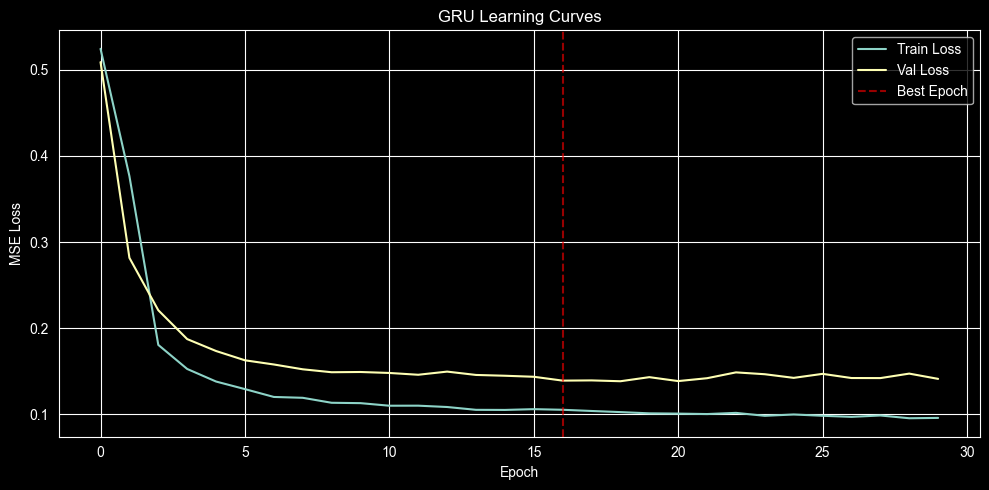

In [9]:

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.axvline(best_epoch - 1, color='red', linestyle='--', alpha=0.6, label='Best Epoch')
plt.title('GRU Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'gru_learning_curves.png', dpi=150)
plt.show()


## 6. Сравнение моделей и выбор лучшей по validation

In [10]:

results_df = pd.DataFrame(results).T
results_df.index.name = 'experiment_id'
results_df


,mae,rmse,mape
experiment_id,,,
B1,6.415807,8.089288,4.546076
B2,12.678956,15.131408,9.201860
B3,6.687057,8.292055,4.615993
R1,5.115653,6.742994,3.519685


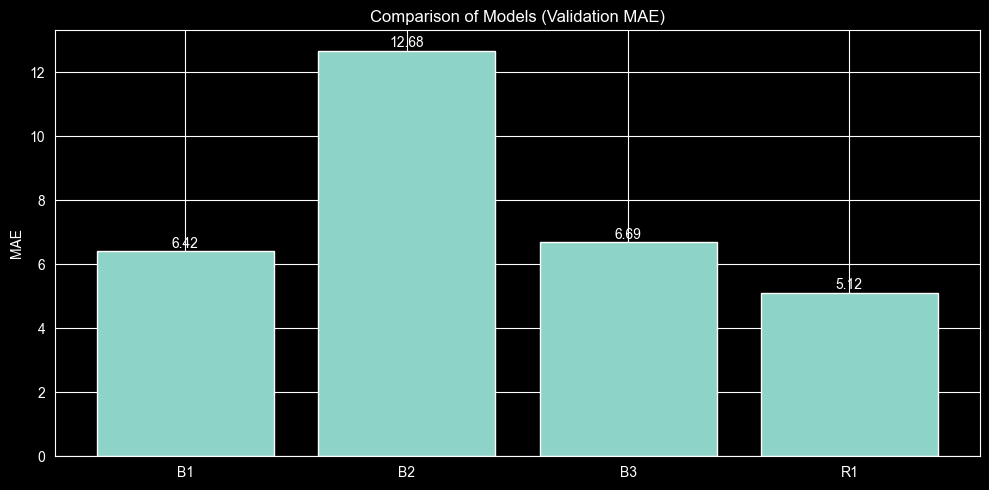

Best model by validation MAE: R1


In [11]:

plt.figure(figsize=(10, 5))
models = ['B1', 'B2', 'B3', 'R1']
maes = [results[m]['mae'] for m in models]
bars = plt.bar(models, maes)
for bar, val in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}', ha='center')
plt.title('Comparison of Models (Validation MAE)')
plt.ylabel('MAE')
plt.tight_layout()
plt.savefig(FIG_DIR / 'baselines_compare.png', dpi=150)
plt.show()

best_exp_id = min(results, key=lambda x: results[x]['mae'])
print('Best model by validation MAE:', best_exp_id)


## 7. Один финальный test для лучшей модели

{'test_mae': 7.59151029586792, 'test_rmse': 9.249570269525954, 'test_mape': 4.865354537963867}


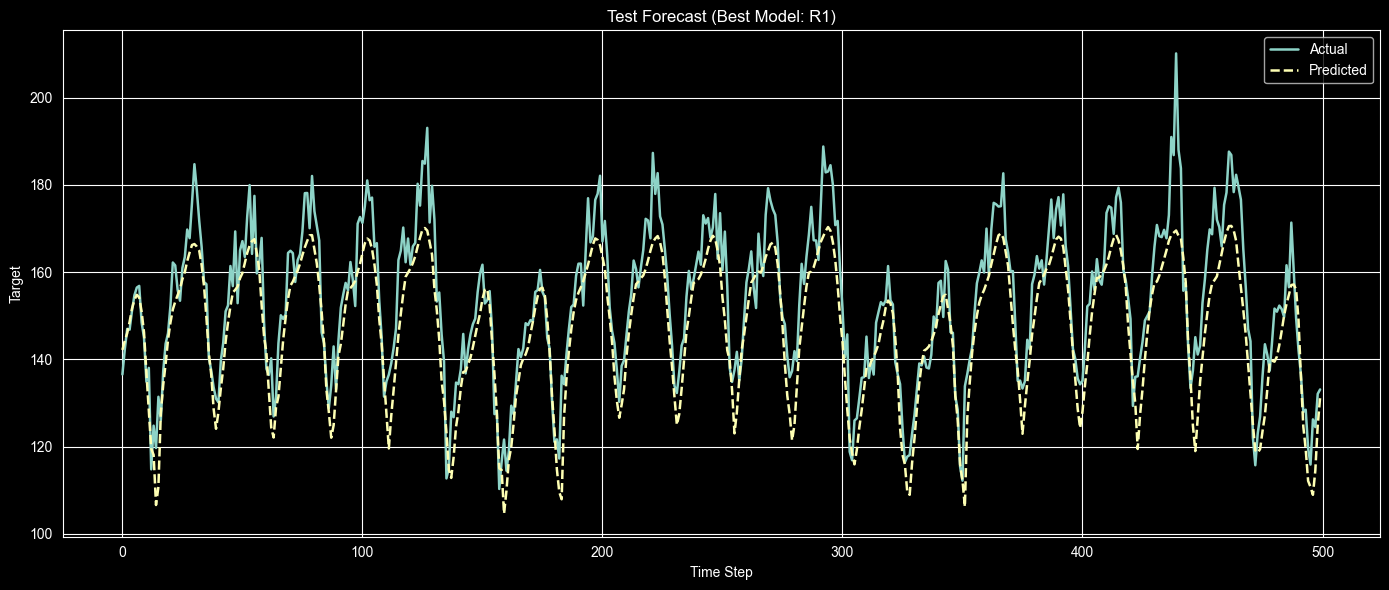

In [12]:

if best_exp_id == 'R1':
    test_eval = evaluate_loader(model, test_loader)
    test_mae, test_rmse, test_mape = test_eval['mae'], test_eval['rmse'], test_eval['mape']
    plot_true, plot_pred = test_eval['targets_orig'], test_eval['preds_orig']
elif best_exp_id == 'B3':
    pred_test = ridge.predict(X_test_scaled)
    test_mae, test_rmse, test_mape = calc_metrics(y_test, pred_test)
    plot_true, plot_pred = y_test, pred_test
elif best_exp_id == 'B2':
    pred_test = test_df['rolling_mean_7'].values
    test_mae, test_rmse, test_mape = calc_metrics(y_test, pred_test)
    plot_true, plot_pred = y_test, pred_test
else:
    pred_test = test_df['lag_1'].values
    test_mae, test_rmse, test_mape = calc_metrics(y_test, pred_test)
    plot_true, plot_pred = y_test, pred_test

print({'test_mae': test_mae, 'test_rmse': test_rmse, 'test_mape': test_mape})

plt.figure(figsize=(14, 6))
n_points = min(500, len(plot_true))
plt.plot(plot_true[:n_points], label='Actual', linewidth=1.8)
plt.plot(plot_pred[:n_points], label='Predicted', linestyle='--', linewidth=1.8)
plt.title(f'Test Forecast (Best Model: {best_exp_id})')
plt.xlabel('Time Step')
plt.ylabel('Target')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_forecast_test.png', dpi=150)
plt.show()


## 8. Сохранение runs.csv и конфигурации лучшей GRU

In [13]:

config = {
    'window_size': WINDOW_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,
    'seed': SEED,
    'input_features': feature_cols,
    'scaler': 'StandardScaler'
}
with open(ART_DIR / 'best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=4)

rows = [
    ['B1','forecasting','S12-hw-dataset',SEED,split_summary,'',1,'Naive Last','lag_1','', '',1.0,0,
     results['B1']['mae'], results['B1']['rmse'], results['B1']['mape'], '', '', '', 'Baseline'],
    ['B2','forecasting','S12-hw-dataset',SEED,split_summary,7,1,'Moving Average','rolling_mean_7','', '',1.0,0,
     results['B2']['mae'], results['B2']['rmse'], results['B2']['mape'], '', '', '', 'Baseline'],
    ['B3','forecasting','S12-hw-dataset',SEED,split_summary,'',1,'Ridge Regression',
     'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, hour, day_of_week, is_weekend',
     'StandardScaler', 'Closed Form', 1.0, 0,
     results['B3']['mae'], results['B3']['rmse'], results['B3']['mape'], '', '', '', 'Linear Model'],
    ['R1','forecasting','S12-hw-dataset',SEED,split_summary,WINDOW_SIZE,1,f'GRU({HIDDEN_SIZE}, {NUM_LAYERS})',
     'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, hour, day_of_week, is_weekend',
     'StandardScaler', 'Adam', LEARNING_RATE, EPOCHS,
     results['R1']['mae'], results['R1']['rmse'], results['R1']['mape'], test_mae, test_rmse, test_mape, 'Deep Learning']
]

runs_df = pd.DataFrame(rows, columns=['experiment_id','task','dataset','seed','split_summary','window_size','horizon',
                                      'model_summary','features_summary','scaler','optimizer','lr','epochs_trained',
                                      'best_val_mae','best_val_rmse','best_val_mape','test_mae','test_rmse','test_mape','notes'])
runs_df.to_csv(ART_DIR / 'runs.csv', index=False)
runs_df


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,Train: 2025-01-01 00:00:00 - 2025-04-18 23:00:...,,1,Naive Last,lag_1,,,1.000,0,6.415807,8.089288,4.546076,,,,Baseline
1,B2,forecasting,S12-hw-dataset,42,Train: 2025-01-01 00:00:00 - 2025-04-18 23:00:...,7,1,Moving Average,rolling_mean_7,,,1.000,0,12.678956,15.131408,9.201860,,,,Baseline
2,B3,forecasting,S12-hw-dataset,42,Train: 2025-01-01 00:00:00 - 2025-04-18 23:00:...,,1,Ridge Regression,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler,Closed Form,1.000,0,6.687057,8.292055,4.615993,,,,Linear Model
3,R1,forecasting,S12-hw-dataset,42,Train: 2025-01-01 00:00:00 - 2025-04-18 23:00:...,7,1,"GRU(48, 2)","lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler,Adam,0.001,30,5.115653,6.742994,3.519685,7.59151,9.24957,4.865355,Deep Learning
